# Week 4a.1: LangGraph Basics

We've seen how to build an agent with `create_agent`, which runs the whole propose-execute-return loop for us. Today we'll take a closer look at how it works. 

`create_agent` is built on [**LangGraph**](https://docs.langchain.com/oss/python/langgraph/graph-api), a library for describing agents as graphs. If we understand the graph layer, we can build flows that `create_agent` cannot give us such as branching logic and state management.

We'll start by building a first graph, a sequential chain, and a router.

In [1]:
from dotenv import load_dotenv
import os

load_dotenv()
assert os.getenv("GOOGLE_API_KEY"), "No GOOGLE_API_KEY found."
print("API key loaded")

API key loaded


## 0. Model Setup

Execute one of the following to define the model.

If using Ollama, you will need to start it first (simply open the chat UI and send a message):
- https://docs.langchain.com/oss/python/integrations/chat/ollama

Verify that Ollama is serving a model:
- http://localhost:11434/

In [3]:
from langchain_ollama import ChatOllama

model = ChatOllama(model="qwen3.5:4b", reasoning=False)

In [ ]:
from langchain.chat_models import init_chat_model

model = init_chat_model(model="gpt-4.1-mini")

In [2]:
from langchain_google_genai import ChatGoogleGenerativeAI

model = ChatGoogleGenerativeAI(model="gemini-3.5-flash-lite")

In [5]:
# run in terminal: uv pip install langchain_openrouter

from langchain_openrouter import ChatOpenRouter

model = ChatOpenRouter(model="google/gemma-4-31b-it:free", max_retries=4)

In [ ]:
# run in terminal: uv pip install langchain_nvidia_ai_endpoints
from langchain_nvidia_ai_endpoints import ChatNVIDIA
model = ChatNVIDIA(model="nvidia/nemotron-3.5-lightning-30b-a3b", reasoning=False)
#model = ChatNVIDIA(model="meta/muse-glimmer-30b")

In [3]:
model.invoke("What's an embedding in one sentence")

Direct use of automatic function calling (AFC) in Models.generate_content is not recommended. Instead, we recommend to use AFC in Chat.send_message. Similarly, direct use of AFC in Models.generate_content_stream is not recommended. Instead, we recommend to use AFC in Chat.send_message_stream.


AIMessage(content=[{'type': 'text', 'text': 'An embedding is a way of representing words, sentences, or data as numbers in a shared space so that computers can understand their semantic meanings and relationships.', 'extras': {'signature': 'EmAKXgFpFH0TFycisQoFoSRWSDmYwis4IukulMGyHsXvRSJdRXEfDTIv6UFDzPFUR1ZoW1hIzzyLVucZ75RXX4Ao9zQefVHc2s2R2FW2+8LpL9ZsnipLT6tFN1y+rBaq48A='}}], additional_kwargs={}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-3.5-flash-lite', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--01a0eedc-f4cd-7f10-b7e3-3fc3adc084c7-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 9, 'output_tokens': 30, 'total_tokens': 39, 'input_token_details': {'cache_read': 0}})

## 1. A Simple Graph: The three core elements

Every LangGraph application is built from three things:

- **State**: a shared data structure that every step can read and update. We define its shape with a `TypedDict`.
- **Nodes**: plain Python functions. A node receives the current state and returns a dictionary containing only the keys it wants to update.
- **Edges**: connections that decide which node runs next. `START` and `END` mark where execution enters and leaves the graph.

Docs: https://docs.langchain.com/oss/python/langgraph/graph-api

In [4]:
from typing import Literal, TypedDict

class State(TypedDict):
    message: str

A node is an ordinary function. It takes the state and returns the update it wants to make.

In [5]:
def add_greeting(state: State) -> dict:
    return {"message": "Hello, " + state["message"]}

In [6]:
from langgraph.graph import StateGraph, START, END

# TODO
# construct the state graph 
builder = StateGraph(State) # Planning to use a state graph to manage the flow of states in a conversational AI application.

# add the node "add_greeting"
builder.add_node("greeting", add_greeting)
# add the edges: START -> add_greeting -> END
builder.add_edge(START, "greeting")
builder.add_edge("greeting", END)

# compile the StateGraph
graph = builder.compile()


Note: in LangGraph, the nodes always need a start node, and end node. 

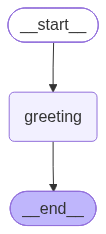

In [7]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

### Invoking a Graph
Runs the graph with an input by sending a state message through the entire graph

`invoke` takes a dictionary shaped like the state and returns the final state. 

Each node's return value overwrites the specified state element(s)

In [8]:
graph.invoke({"message":"Agentic AI class"})

{'message': 'Hello, Agentic AI class'}

<hr />

## 2. A sequential graph
Let's now add multiple nodes sequentially.

Construction always involves the same steps:
 - Instantiate a builder around the state
 - Add nodes
 - Add edges
 - Compile.

This is the graph we are about to build:

<img src="figures/graph_sequential.png" width="230" alt="sequential graph">

In [9]:
def add_greeting(state: State) -> dict:
    return {"message": "Hello, " + state["message"]}

def shout(state: State) -> dict:
    return {"message": state["message"].upper() + "!"}

In [10]:
from langgraph.graph import StateGraph, START, END

# construct the state graph
builder = StateGraph(State)

# add nodes
builder.add_node("add_greeting", add_greeting)
builder.add_node("shout", shout)

# add edges START -> add_greeting -> shout -> END
builder.add_edge(START, "add_greeting")
builder.add_edge("add_greeting", "shout")
builder.add_edge("shout", END)

# compile the StateGraph
graph = builder.compile()


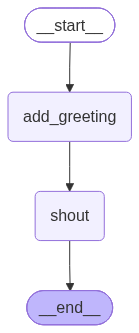

In [11]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

In [12]:
graph.invoke({"message": "agentic AI class"})

{'message': 'HELLO, AGENTIC AI CLASS!'}

In [13]:
for chunk in graph.stream({"message": "agentic AI class"}, stream_mode="values"):
    print("Stream step state:", chunk)

Stream step state: {'message': 'agentic AI class'}
Stream step state: {'message': 'Hello, agentic AI class'}
Stream step state: {'message': 'HELLO, AGENTIC AI CLASS!'}


**Notice there is no LLM anywhere yet. A graph is just orchestration; what runs inside each node is up to us.**

## 3. A chain

We'll now put a model inside the nodes. This is the **prompt chaining** pattern from the Week 1 reading (Building Effective Agents): each step's output becomes the next step's input, and the route through the graph is fixed.

<img src="figures/graph_chain.png" width="230" alt="sequential chain">

In [14]:
class JokeState(TypedDict):
    topic: str
    joke: str
    improved_joke: str

In [15]:
def write_joke(state: JokeState) -> dict:
    response = model.invoke(f"Write a short, clean joke about {state['topic']}.")
    return {"joke": response.text}

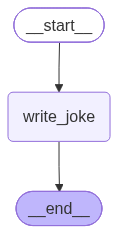

{'topic': 'college professors', 'joke': 'Why do college professors love daylight saving time?\n\nBecause once a year, they get to give a brilliant, one-hour lecture on how tired they are.'}


In [16]:
chain_builder = StateGraph(JokeState)

# add node: write_joke
chain_builder.add_node("write_joke", write_joke)

# add edges: START -> write_joke -> improve_joke -> END
chain_builder.add_edge(START, "write_joke")
chain_builder.add_edge("write_joke", END)

chain = chain_builder.compile()

display(Image(chain.get_graph().draw_mermaid_png()))

result = chain.invoke({"topic": "college professors"})
print(result)

In [17]:
print(result["joke"])

Why do college professors love daylight saving time?

Because once a year, they get to give a brilliant, one-hour lecture on how tired they are.


One practical detail: we need to store `response.text`, not `response.content`. 

Some providers (Gemini included) return `content` as a list of content blocks rather than a plain string; `.text` always gives you the reply as a string.

In [18]:
def improve_joke(state: JokeState) -> dict:
    response = model.invoke(f"Make this joke funnier: {state['joke']}")
    return {"improved_joke": response.text}

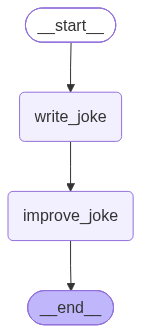

{'topic': 'college professors', 'joke': 'Why do college professors love daylight saving time?\n\nBecause once a year, they get to give a one-hour lecture in forty minutes.', 'improved_joke': 'Your original joke is actually structurally very solid! To make it funnier, we just need to punch up the imagery, play on the infamous stereotypes of academic arrogance, or lean harder into the sheer misery of the students. \n\nHere are a few ways to punch it up, depending on the vibe you want:\n\n**Option 1: Lean into the academic ego (Best for a dry, sarcastic delivery)**\n> "Why do college professors love daylight saving time? \n> Because once a year, they legally get to cram 60 minutes of unsolicited life advice into 40 minutes."\n\n**Option 2: Lean into the student suffering (Most relatable)**\n> "Why do college professors love daylight saving time?\n> Because it\'s the one day a year they can legally hold students hostage for an hour, but finish 20 minutes early and still act like they did t

In [19]:
#TODO: write the second node, improve_joke.
# It should ask the model to make state['joke'] funnier by adding a follow-up line,
# and return the result under the key 'improved_joke'.

chain_builder = StateGraph(JokeState)

# add node: write_joke
chain_builder.add_node("write_joke", write_joke)
chain_builder.add_node("improve_joke", improve_joke)

# add edges: START -> write_joke -> improve_joke -> END
chain_builder.add_edge(START, "write_joke")
chain_builder.add_edge("write_joke", "improve_joke")
chain_builder.add_edge("improve_joke", END)

chain = chain_builder.compile()

display(Image(chain.get_graph().draw_mermaid_png()))

result = chain.invoke({"topic": "college professors"})
print(result)


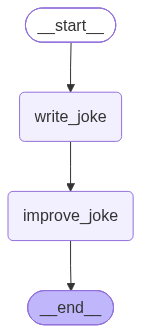

In [20]:
chain_builder = StateGraph(JokeState)

# add nodes: write_joke and improve_joke
chain_builder.add_node("write_joke", write_joke)
chain_builder.add_node("improve_joke", improve_joke)

# add edges: START -> write_joke -> improve_joke -> END
chain_builder.add_edge(START, "write_joke")
chain_builder.add_edge("write_joke", "improve_joke")
chain_builder.add_edge("improve_joke", END)

chain = chain_builder.compile()
display(Image(chain.get_graph().draw_mermaid_png()))

In [21]:
result = chain.invoke({"topic": "college professors"})

print(result["joke"])
print("---")
print(result["improved_joke"])

Why do college professors love international holidays?

It’s the only time they get a full semester's worth of reading done.
---
Here are a few ways to punch up the joke, depending on the vibe you’re going for:

**Option 1: Punchier and more relatable (Best for a quick laugh)**
> "Why do college professors love international holidays?"
> "It’s the only time they actually finish grading a semester’s worth of papers."
*(Why it works: Swapping "reading" for "grading" hits closer to the professor stereotype of dreading grading piles of student essays.)*

**Option 2: Self-deprecating academic humor**
> "Why do college professors love international holidays?"
> "Because it’s the only time they can fake reading a textbook and actually get away with it."

**Option 3: The "Syllabus" angle**
> "Why do college professors love international holidays?"
> "It’s the only time they have enough free time to update their syllabus from 2014."

**Option 4: Short & Dry (One-liner style)**
> "College profes

In [22]:
for chunk in chain.stream({"topic": "college professors"}, stream_mode="values"):
    print("Stream step state:", chunk)

Stream step state: {'topic': 'college professors'}
Stream step state: {'topic': 'college professors', 'joke': 'Why do college professors love daylight saving time?\n\nBecause once a year, they get to give a 50-minute lecture that officially lasts for an hour.'}
Stream step state: {'topic': 'college professors', 'joke': 'Why do college professors love daylight saving time?\n\nBecause once a year, they get to give a 50-minute lecture that officially lasts for an hour.', 'improved_joke': 'Here are a few ways to punch it up, depending on the vibe you want:\n\n**Option 1: Lean into the academic ego (Best for dry humor)**\n> "Why do college professors love the end of Daylight Saving Time?\n> Because it’s the only day of the year they can drone on for an extra hour and legally claim it was part of the syllabus."\n\n**Option 2: The "Tenured" angle**\n> "Why do college professors love the "fall back" time change?\n> Because it gives them 60 minutes to explain a concept that could easily be cove

The model did the writing, but it made no decisions about control flow. The route was fixed when we drew the edges. That makes this a **workflow**, not an agent.

## 4. A router

So far every edge was fixed, with no branching/decision making. 

A **conditional edge** is used to make branching decisions. A conditional edge needs a function that inspects the state and returns the name of the node to run next.

The example: a support desk that triages incoming messages to a billing team or a general queue.

In these diagrams, solid arrows are fixed edges; **dashed red arrows are conditional edges**, where the next node is decided at runtime:

<img src="figures/graph_router.png" width="340" alt="router graph">

In [23]:
class SupportState(TypedDict):
    message: str
    reply: str

def billing(state: SupportState) -> dict:
    return {"reply": "Billing team: we will review the charge on your account."}

def general(state: SupportState) -> dict:
    return {"reply": "Support: thanks for reaching out, how can we help?"}

The following cell deals with nodes and points to the router returning the node name. 
You can use an annotation to limit the possability between billing and general 

In [ ]:
# the router function needs to return a node name
def route(state: SupportState) -> Literal["billing", "general"]:
    text = state["message"].lower()
    if any(word in text for word in ["refund", "charge", "billing", "payment"]): # this line checks for any word related to billing in the user's message and searches the nodes for words
        return "billing"
    return "general"

In [25]:
support_messages = [SupportState(message="I want a refund for my order"),
           SupportState(message="Do you ship to Canada?")]

In [26]:
route(support_messages[1])

'general'

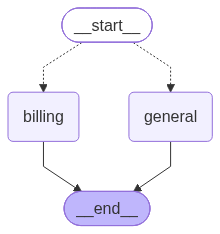

In [ ]:
router_builder = StateGraph(SupportState)

router_builder.add_node("billing", billing)
router_builder.add_node("general", general)

# TODO: add the conditional edge from the start node to route
router_builder.add_conditional_edges(START, route) # this conditional edge specifies the routing route. It will either go to billing or general.
router_builder.add_edge("billing", END)
router_builder.add_edge("general", END)

router = router_builder.compile()
display(Image(router.get_graph().draw_mermaid_png()))

### Adding a Fake Router Node
Not really a node because it doesn't process the state
- To the router node, add a lambda function that retuns the state as is: lambda state:state. 
- Visually this helps Prof. 

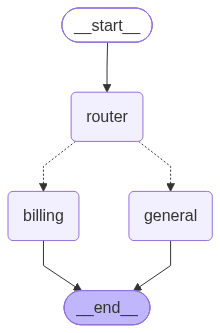

In [30]:
router_builder = StateGraph(SupportState)

router_builder.add_node("billing", billing)
router_builder.add_node("general", general)
# TODO: add the fake add node with lambda function
router_builder.add_node("router", lambda state:state) # dummy node to represent the routing decision point. It doesn't perform any action itself, but serves as a placeholder for the conditional routing logic.

# TODO: add the edge START -> router and conditional edge
router_builder.add_edge(START, "router") # we now starts at the route node instead of start. 
router_builder.add_conditional_edges("router", route)
router_builder.add_edge("billing", END)
router_builder.add_edge("general", END)

router = router_builder.compile()
display(Image(router.get_graph().draw_mermaid_png()))

In [31]:
print(router.invoke(support_messages[0])["reply"])

Billing team: we will review the charge on your account.


In [32]:
print(router.invoke(support_messages[1])["reply"])

Support: thanks for reaching out, how can we help?


The routing logic is hard-coded keywords, and keywords are brittle. "My card was hit twice for one order" is clearly a billing problem, but none of our keywords appear in it. Let the model classify instead. It's easier to use an LLM route to handle it. it can be unpredictable though

In [33]:
def llm_route(state: SupportState) -> Literal["billing", "general"]:
    response = model.invoke(
        "Classify this customer message as billing or general. "
        "Answer with exactly one word: billing or general.\n\n"
        f"Message: {state['message']}"
    )
    answer = response.text.strip().lower()
    return "billing" if "billing" in answer else "general"

In [34]:
llm_route(support_messages[1])

'general'

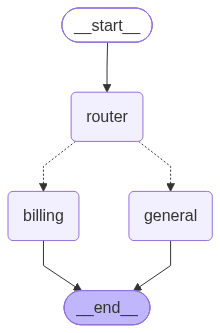

In [35]:
llm_router_builder = StateGraph(SupportState)

llm_router_builder.add_node("billing", billing)
llm_router_builder.add_node("general", general)
llm_router_builder.add_node("router", lambda state:state)

llm_router_builder.add_edge(START, "router")
llm_router_builder.add_conditional_edges("router", llm_route)
llm_router_builder.add_edge("billing", END)
llm_router_builder.add_edge("general", END)

llm_router = llm_router_builder.compile()

display(Image(llm_router.get_graph().draw_mermaid_png()))


In [36]:
print(llm_router.invoke({"message": "I have two transactions for the same order." }))

{'message': 'I have two transactions for the same order.', 'reply': 'Billing team: we will review the charge on your account.'}


In [37]:
print(llm_router.invoke({"message": "How can I return my order?" })["reply"])

Support: thanks for reaching out, how can we help?


In [38]:
for chunk in llm_router.stream(support_messages[0], stream_mode="values"):
    print("Stream step state:", chunk)

Stream step state: {'message': 'I want a refund for my order'}
Stream step state: {'message': 'I want a refund for my order'}
Stream step state: {'message': 'I want a refund for my order', 'reply': 'Billing team: we will review the charge on your account.'}


An agent needs more: decide, act, look at the result, decide again. That takes a loop in the graph, and the model's **tool calls** become the routing signal. That is what we'll cover next.